# EI Tuning — Wilson-Cowan Whole-Brain Model

각 셀은 독립적인 파트를 담당한다. **파라미터 수정은 Cell 2에서만 한다.**

In [1]:
# JAX 메모리 설정: import 전에 반드시 실행해야 한다
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_ALLOCATOR", "platform")

import jax
jax.config.update("jax_enable_x64", False)

print(f"backend : {jax.default_backend()}")
print(f"devices : {jax.devices()}")
print(f"jax_enable_x64 : {jax.config.jax_enable_x64}")

from config              import Config
from data_loader         import load_data
from model               import build_network
from part1_fic           import run_fic
from part2_eib           import run_eib
from part3_gradient      import run_gradient_optimization, run_lowrank_optimization
from part4_dbs           import run_dbs_stimulation
from pipeline_contracts  import ParamSet, StateBundle, capture_internal_state, capture_network_delay_history


backend : gpu
devices : [CudaDevice(id=0)]
jax_enable_x64 : False


## Cell 2 — Config

**파라미터 수정은 이 셀에서만 한다.**

## Dataset 선택

`dataset = "mouse"` 또는 `"human"` 으로 설정하면
Wilson-Cowan 파라미터와 FIC 설정, 데이터 파일이 자동으로 전환된다.

In [2]:
# ── Dataset 선택 ───────────────────────────────
# "mouse" 또는 "human"
dataset = "human"

_DATASET_PARAMS = {
    "human": dict(
        # SanzLeonet et al. 2014 — frequency peak at 20 Hz
        wc_c_ee=10.0, wc_c_ei=6.0, wc_c_ie=10.0, wc_c_ii=1.0,
        wc_r_e=0.0,  wc_r_i=0.0,
        wc_tau_e=10.0, wc_tau_i=10.0,
        wc_alpha_e=1.2, wc_alpha_i=2.0,
        wc_theta_e=2.0, wc_theta_i=3.5,
        wc_k_e=1.0, wc_k_i=1.0,
        wc_a_e=1.0, wc_a_i=1.0,
        wc_b_e=0.0, wc_b_i=0.0,
        wc_c_e=1.0, wc_c_i=1.0,
        wc_P=0.5, wc_Q=0.0, wc_lamda=1.0,
        wc_rE_max_hz=20.0, wc_rI_max_hz=20.0,
        wc_c_ei_init=6.0,
        fic_target_firing_rate_hz=4.0,
        # DBS targets (PD25subcortex, 0-based node index)
        dbs_target_regions={
            'STN_L': 404,  # Left_subthalamic_nucleus
            'GPe_L': 410,  # Left_globus_pallidus_externa
            'GPe_R': 411,  # Right_globus_pallidus_externa
            'GPi_L': 412,  # Left_globus_pallidus_interna
        },
        # Bold HRF: library defaults for human
        bold_hrf_k1=5.6,
        bold_hrf_V0=0.02,
        bold_hrf_tau_s=0.8,
        bold_hrf_tau_f=0.4,
        bold_hrf_scaling=1.0 / 3.0,
        bold_hrf_duration_ms=20_000.0,  # 20s (library default)
        sc_csv='human/weight.csv',
        length_csv='human/tract_length.csv',
        fc_csv='human/fc_matrix.csv',
        region_txt='human/Custom_Schaefer400_PD25subcortex_1mm.txt',
        tract_conduction_speed=1.0,
        additive_noise_sigma=0.01,
    ),
    "mouse": dict(
        # Current mouse parameters
        wc_c_ee=11.0, wc_c_ei=10.0, wc_c_ie=10.0, wc_c_ii=1.0,
        wc_r_e=1.0,  wc_r_i=1.0,
        wc_tau_e=10.0, wc_tau_i=10.0,
        wc_alpha_e=1.2, wc_alpha_i=2.0,
        wc_theta_e=2.0, wc_theta_i=3.5,
        wc_k_e=1.0, wc_k_i=1.0,
        wc_a_e=1.0, wc_a_i=1.0,
        wc_b_e=0.0, wc_b_i=0.0,
        wc_c_e=1.0, wc_c_i=1.0,
        wc_P=0.5, wc_Q=0.0, wc_lamda=1.0,
        wc_rE_max_hz=20.0, wc_rI_max_hz=20.0,
        wc_c_ei_init=10.0,
        fic_target_firing_rate_hz=4.0,
        # DBS targets (Atlas_43, 0-based node index)
        dbs_target_regions={
            'STN_L': 11,
            'GPe_L': 5,
            'GPe_R': 6,
            'GPi_L': 7,
        },
        # Bold HRF: mouse-specific
        bold_hrf_k1=5.6,
        bold_hrf_V0=0.02,
        bold_hrf_tau_s=0.8,
        bold_hrf_tau_f=0.4,
        bold_hrf_scaling=1.0 / 3.0,
        bold_hrf_duration_ms=32_000.0,  # 32s (mouse-specific)
        sc_csv='mouse/weight_nor.csv',
        length_csv='mouse/tract_length_nor.csv',
        fc_csv='mouse/FC_nor.csv',
        region_txt='mouse/Atlas_43.txt',
        tract_conduction_speed=3.0,
        additive_noise_sigma=0.02,
    ),
}

_p = _DATASET_PARAMS[dataset]
print(f'Dataset: {dataset}')
print(f'  c_ee={_p["wc_c_ee"]}  c_ei={_p["wc_c_ei"]}  r_e={_p["wc_r_e"]}')
print(f'  fic_target={_p["fic_target_firing_rate_hz"]} Hz  c_ei_init={_p["wc_c_ei_init"]}')
print(f'  sc_csv={_p["sc_csv"]}')

Dataset: human
  c_ee=10.0  c_ei=6.0  r_e=0.0
  fic_target=4.0 Hz  c_ei_init=6.0
  sc_csv=human/weight.csv


In [3]:
cfg = Config(
    # ── 데이터 경로 ──────────────────────────────────────────
    region_txt                          = _p["region_txt"],
    sc_csv                              = _p["sc_csv"],
    length_csv                          = _p["length_csv"],
    fc_csv                              = _p["fc_csv"],
    cache_version                       = "v_eituning_oldlogic_match_p3_p7_p8_p9_pm_p12_p13_p14_ce10_p15_p19_p21_p22_human",
    cache_root_dir                      = "./cache/cache/human",

    # ── 시뮬레이션 공통 ──────────────────────────────────────
    integration_dt_ms                   = 1.0,
    warmup_duration_ms                  = 720_000,
    # -- Patch 13: Bold HRF parameters -------------------
    bold_hrf_k1          = _p["bold_hrf_k1"],
    bold_hrf_V0          = _p["bold_hrf_V0"],
    bold_hrf_tau_s       = _p["bold_hrf_tau_s"],
    bold_hrf_tau_f       = _p["bold_hrf_tau_f"],
    bold_hrf_scaling     = _p["bold_hrf_scaling"],
    bold_hrf_duration_ms = _p["bold_hrf_duration_ms"],

    bold_repetition_time_ms             = 1000.0,
    tract_conduction_speed              = _p["tract_conduction_speed"],
    additive_noise_sigma                = _p["additive_noise_sigma"],

    # ── Part 1 — FIC (구버전 notebook 로직) ─────────────────
    fic_target_firing_rate_hz           = _p["fic_target_firing_rate_hz"],
    fic_learning_rate                   = 1e-3,
    fic_max_iterations                  = 2000,
    fic_early_stop_patience             = 500,
    fic_early_stop_tolerance_hz         = 0.10,
    fic_step_duration_ms                = 1_000,
    fic_step_skip_tr                    = 0,

    # ── Part 2 — EIB (구버전 notebook 로직) ─────────────────
    eib_max_iterations                  = 8000,
    eib_internal_fic_learning_rate      = 0.05,
    eib_max_weight_learning_rate        = 0.002,
    eib_bold_window_samples             = 720,
    eib_snapshot_save_interval          = 50,
    connectivity_weight_max             = 1.5,

    eib_posthoc_duration_ms             = 720_000,
    eib_posthoc_skip_tr                 = 60,

    # ── Part 3 — Full Gradient (구버전 notebook 로직) ───────
    optimizer_learning_rate             = 0.0005,
    optimizer_max_steps                 = 1000,
    optimizer_chunk_steps               = 10,
    optimizer_bold_window_tr            = 720,
    optimizer_bold_skip_tr              = 60,

    # ── Part 3B — Low-rank (사용자 지정: Full Gradient 결과 기반) ──
    lowrank_rank                        = 6,
    lowrank_max_steps                   = 300,
    lowrank_learning_rate               = 0.0002,
    lowrank_bold_window_tr              = 720,
    lowrank_bold_skip_tr                = 60,
    lowrank_delta_scale                 = 0.15,
    lowrank_factor_init                 = 0.01,
    lowrank_activity_weight             = 0.01,
    lowrank_factor_penalty              = 1e-4,
    lowrank_seed                        = 17,

    # ── Phase 1 final baseline settle ────────────────────────
    baseline_settle_duration_ms         = 0,

    # ── EIB score 계산용 ──────────────────────────────────────
    pd_fit_region_count                 = 14,
    full_brain_fc_loss_weight           = 1.00,
    pd_fit_block_loss_weight            = 0.00,
    correlation_loss_weight             = 0.80,   # EIB scoring (keep)
    rmse_loss_weight                    = 0.20,   # EIB scoring (keep)

    # ── Patch 9: Gradient / LowRank 3-term loss weights ──────
    optimizer_global_corr_weight        = 0.40,   # alpha: global FC corr
    optimizer_nodewise_corr_weight      = 0.40,   # beta:  node-wise FC corr
    optimizer_rmse_weight               = 0.20,   # gamma: global FC RMSE
    lowrank_global_corr_weight          = 0.40,
    lowrank_nodewise_corr_weight        = 0.40,
    lowrank_rmse_weight                 = 0.20,

    # ── Part 4 — DBS ─────────────────────────────────────────
    # DBS target regions (dataset-specific)
    dbs_target_regions               = _p["dbs_target_regions"],

    dbs_pulse_amplitude                 = 10.0,
    dbs_stimulation_frequency_hz        = 130.0,
    dbs_phase_duration_steps            = 1,
    dbs_pre_stimulation_duration_ms     = 60_000.0,
    dbs_stimulation_duration_ms         = 60_000.0,

    # ── WC model params (dataset별 자동 설정, Patch 15) ─────
    wc_c_ee      = _p["wc_c_ee"],
    wc_c_ei      = _p["wc_c_ei"],
    wc_c_ie      = _p["wc_c_ie"],
    wc_c_ii      = _p["wc_c_ii"],
    wc_r_e       = _p["wc_r_e"],
    wc_r_i       = _p["wc_r_i"],
    wc_tau_e     = _p["wc_tau_e"],
    wc_tau_i     = _p["wc_tau_i"],
    wc_alpha_e   = _p["wc_alpha_e"],
    wc_alpha_i   = _p["wc_alpha_i"],
    wc_theta_e   = _p["wc_theta_e"],
    wc_theta_i   = _p["wc_theta_i"],
    wc_k_e       = _p["wc_k_e"],
    wc_k_i       = _p["wc_k_i"],
    wc_a_e       = _p["wc_a_e"],
    wc_a_i       = _p["wc_a_i"],
    wc_b_e       = _p["wc_b_e"],
    wc_b_i       = _p["wc_b_i"],
    wc_c_e       = _p["wc_c_e"],
    wc_c_i       = _p["wc_c_i"],
    wc_P         = _p["wc_P"],
    wc_Q         = _p["wc_Q"],
    wc_lamda     = _p["wc_lamda"],
    wc_rE_max_hz = _p["wc_rE_max_hz"],
    wc_rI_max_hz = _p["wc_rI_max_hz"],
    wc_c_ei_init = _p["wc_c_ei_init"],
)
cfg.print_summary()

  Config
  region_txt                                   = human/Custom_Schaefer400_PD25subcortex_1mm.txt
  sc_csv                                       = human/weight.csv
  length_csv                                   = human/tract_length.csv
  fc_csv                                       = human/fc_matrix.csv
  cache_root_dir                               = ./cache/human
  param_save_dir                               = ./optimized_params
  cache_version                                = v_eituning_oldlogic_match_p3_p7_p8_p9_pm_p12_p13_p14_ce10_p15_p19_p21_p22_human
  wc_c_ee                                      = 10.0
  wc_c_ei                                      = 6.0
  wc_c_ie                                      = 10.0
  wc_c_ii                                      = 1.0
  wc_r_e                                       = 0.0
  wc_r_i                                       = 0.0
  wc_tau_e                                     = 10.0
  wc_tau_i                                     = 10.0


## Cell 3 — Data Loading

SC / tract_length / FC 로드 및 전처리. weights/delays/fc_target 행렬을 시각화한다.

Cache stored here: /scratch/home/wog3597/optim/cache/./cache/human/v_eituning_oldlogic_match_p3_p7_p8_p9_pm_p12_p13_p14_ce10_p15_p19_p21_p22_human_N416_scedc854a694_fcbcddcdeb6e


W0601 15:25:25.580359 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
E0601 15:25:25.624578 2428392 ptx_compiler_helpers.cc:132] *** WARNING *** Invoking ptxas with version 12.5.40, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.
W0601 15:25:25.673041 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:25.742565 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:25.839325 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:25.891413 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:25.931332 2428392 sol_gpu_cost_model.cc:102] No SoL con

[DATA] n_nodes=416  SC nonzero=11584
[DATA] weights:   min=0.0000e+00  max=1.0000e+00
[DATA] fc_target: min=-5.6307e-01  max=8.9602e-01
[DATA] delays:    min=0.00ms  max=199.00ms  (speed=1.0 mm/ms)
[DATA] SC mask:   11584 / 173056  (6.7%)
[DATA] cache_tag = v_eituning_oldlogic_match_p3_p7_p8_p9_pm_p12_p13_p14_ce10_p15_p19_p21_p22_human_N416_scedc854a694_fcbcddcdeb6e
[DATA] Graph type: DenseDelayGraph


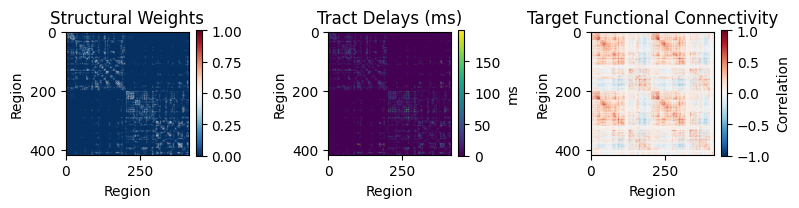

In [4]:
data = load_data(cfg)


## Cell 4 — Build Network & Warmup

In [5]:
network, initial_state, bold_monitor, warmup_result = build_network(cfg, data)

initial_params = ParamSet.default(data["n_nodes"], c_ei_init=cfg.wc_c_ei_init).sanitize(
    data["sc_mask"], cfg.connectivity_weight_max
)

bundle_init = StateBundle.from_warmup(
    warmup_result          = warmup_result,
    bold_monitor_template  = bold_monitor,
    initial_params         = initial_params,
    internal_state         = capture_internal_state(initial_state),
    delay_history          = capture_network_delay_history(network),
    stage                  = "warmup",
)

print(bundle_init)

W0601 15:25:26.578081 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:26.599123 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:26.639907 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:26.679281 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:26.716513 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:26.740934 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:26.777751 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:26.797714 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

[MODEL] Running warmup simulation...


W0601 15:25:27.645234 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:27.665509 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:27.705793 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:27.905857 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:41.054180 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:41.100042 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:41.137505 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:41.158322 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

[MODEL] Warmup done — E mean=0.9720  I mean=0.9902
[MODEL] Graph type: DenseDelayGraph


W0601 15:25:41.525067 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:41.567179 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:41.605556 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:41.647846 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:41.686350 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:41.707318 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:41.746193 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:41.767857 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

StateBundle(stage='warmup', c_ei_frozen=False, init_dyn_shape=(2, 416))


W0601 15:25:42.995325 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:43.037727 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.


## Pipeline timing diagnostics (read-only, Patch 3)

각 단계의 예상 소요 시간만 표시한다. 시뮬레이션을 실행하지 않으며 캐시를 건드리지 않는다.
JAX backend / device 확인, dispatch latency, 단계별 step×per-step 추정치 합산.

In [6]:
# === Pipeline timing diagnostics (Patch 3) ===
from timing_utils import estimate_stage, print_estimates, print_gpu_summary
import time as _t, jax, jax.numpy as _jnp

print_gpu_summary()

# JAX per-dispatch latency micro-benchmark
_n = data['n_nodes']
_x = _jnp.ones((_n, 2), dtype=_jnp.float32)
_f = jax.jit(lambda x: x * 1.0001 + 0.0001)
_f(_x).block_until_ready()  # warmup
_t0 = _t.perf_counter()
for _ in range(200):
    _x = _f(_x)
_x.block_until_ready()
_jax_latency = (_t.perf_counter() - _t0) / 200
print(f'\nJAX per-dispatch latency ≈ {_jax_latency*1000:.3f} ms (N={_n})')

_tr_ms = cfg.bold_repetition_time_ms
_cost = 0.0008  # GPU 기준 fallback (sim 1ms당 약 0.8ms wall)

# DBS baseline+stim per target: config의 dbs_pre_stimulation_duration_ms + dbs_stimulation_duration_ms
_dbs_pre = getattr(cfg, 'dbs_baseline_duration_ms', None)
if _dbs_pre is None:
    _dbs_pre = getattr(cfg, 'dbs_pre_stimulation_duration_ms', 60_000.0)
_dbs_total_per_target = float(_dbs_pre) + float(cfg.dbs_stimulation_duration_ms)

_estimates = [
    estimate_stage('FIC',
        n_steps=int(cfg.fic_max_iterations),
        fallback_step_sec=cfg.fic_step_duration_ms * _cost),
    estimate_stage('EIB-search',
        n_steps=int(cfg.eib_max_iterations),
        fallback_step_sec=_tr_ms * _cost),
    estimate_stage('EIB-posthoc',
        n_steps=1,
        fallback_step_sec=cfg.eib_posthoc_duration_ms * _cost),
    estimate_stage('Gradient',
        n_steps=int(cfg.optimizer_max_steps),
        fallback_step_sec=cfg.optimizer_bold_window_tr * _tr_ms * _cost),
    estimate_stage('LowRank',
        n_steps=int(cfg.lowrank_max_steps),
        fallback_step_sec=cfg.lowrank_bold_window_tr * _tr_ms * _cost),
    estimate_stage('DBS (per target)',
        n_steps=len(cfg.dbs_target_regions),
        fallback_step_sec=_dbs_total_per_target * _cost),
]
print_estimates(_estimates)

print('\n[hint] Patch 3: cfg.posthoc_parallel=True 시 EIB-posthoc ~20-30% 단축.')
print('[hint] cfg.optimizer_chunk_steps=5~10 시 Gradient ~10% 단축 (수렴 dynamics 변경 감수).')
print('[hint] 위 예측은 ±50% 오차. 실측은 각 run_* 의 [STAGE] 라인 참조.')

                        JAX backend / device summary                        
             backend: gpu
        device_count: 1
             devices: ['cuda:0']
      default_device: cuda:0
         x64_enabled: False

JAX per-dispatch latency ≈ 0.049 ms (N=416)
            Pipeline timing estimates (analytical + JAX latency)            
[             FIC] steps=  2000  per-step=  800.00ms  total≈26.7min
[      EIB-search] steps=  8000  per-step=  800.00ms  total≈1.78h
[     EIB-posthoc] steps=    10  per-step=576000.00ms  total≈1.60h
[        Gradient] steps=  1000  per-step=576000.00ms  total≈160.00h
[         LowRank] steps=   300  per-step=576000.00ms  total≈48.00h
[DBS (per target)] steps=     4  per-step=96000.00ms  total≈6.4min
----------------------------------------------------------------------------
                          TOTAL (excl. caching, compile)  ≈ 211.93h

[hint] Patch 3: cfg.posthoc_parallel=True 시 EIB-posthoc ~20-30% 단축.
[hint] cfg.optimizer_chunk_steps=5~10 시 Gr

W0601 15:25:43.077553 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:43.123548 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.


## Cell 5 — Part 1: FIC

구버전 notebook 로직: **1초 step × 2000** 반복, `c_ei`는 아직 동결하지 않는다.

Loading fic_v_eituning_oldlogic_match_p3_p7_p8_p9_pm_p12_p13_p14_ce10_p15_p19_p21_p22_human_N416_scedc854a694_fcbcddcdeb6e_rE4_eta0p001_steps2000_dur1000_skip0_fp41b227697071 from cache, last modified 2026-06-01 14:57:01
[FIC] c_ei updated.  mean c_ei = 12.6046  final rE_hz = 4.008 Hz


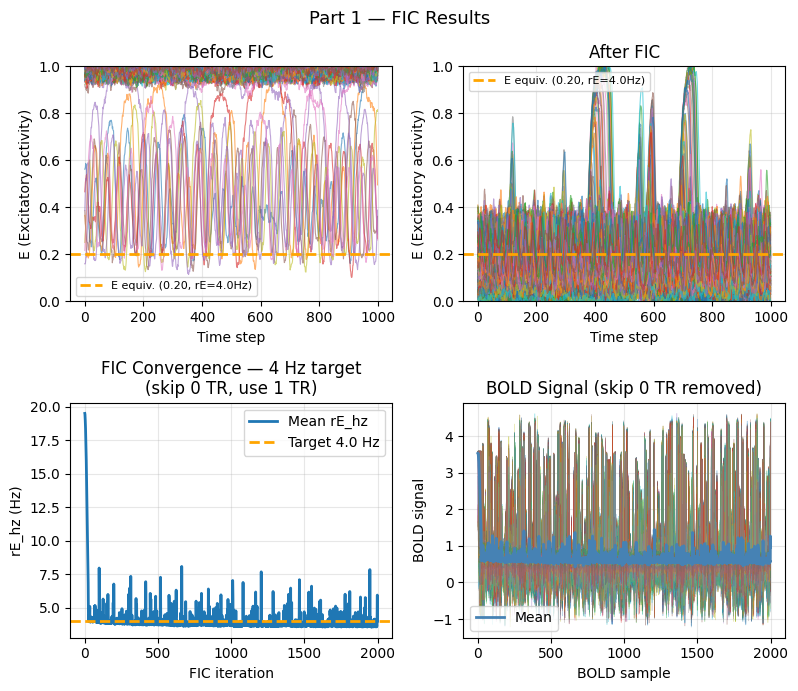

[FIC] FC comparison  Pre-opt corr=-0.0035, Pre-opt rmse=0.2003  Post-FIC corr=0.0189, Post-FIC rmse=0.4846


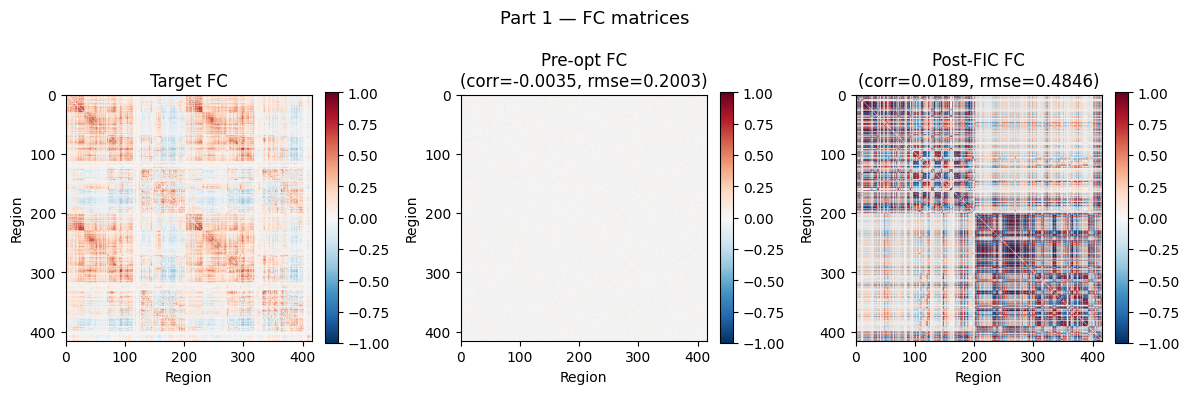

[FIC] c_ei_frozen=False  mean c_ei=12.6046
StateBundle(stage='fic', c_ei_frozen=False, init_dyn_shape=(2, 416))


In [7]:
# Part 1: FIC — 구버전 notebook 로직 (c_ei는 이후 단계에서도 계속 업데이트)
bundle_fic = run_fic(
    network   = network,
    bundle_in = bundle_init,
    cfg       = cfg,
    data      = data,
)
assert not bundle_fic.params.c_ei_frozen, "Old-logic FIC should keep c_ei unfrozen"
print(f"[FIC] c_ei_frozen={bundle_fic.params.c_ei_frozen}  mean c_ei={bundle_fic.params.c_ei.mean():.4f}")
print(bundle_fic)


## Cell 6 — Part 2: EIB Tuning

구버전 notebook 로직: **150 TR window / 8000 step / EIB 중에도 c_ei 업데이트**.

Running computations for eib_v_eituning_oldlogic_match_p3_p7_p8_p9_pm_p12_p13_p14_ce10_p15_p19_p21_p22_human_N416_scedc854a694_fcbcddcdeb6e_win720_etaF0p05_etaE0p002_steps8000_topk10_frozen0_fp1084158d00fb


W0601 15:25:48.811252 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:48.990024 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:49.108785 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:49.129417 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:49.167649 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:49.187557 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:49.207681 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:49.246204 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

[EIB] 1단계 탐색: 8000스텝 × 1 TR  window=720 TR  c_ei_frozen=False
      Step   Win-corr   Win-RMSE  Best-win-corr    Elapsed        ETA
----------------------------------------------------------------------


W0601 15:25:50.211163 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:50.256234 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:50.295145 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:50.335439 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:50.376749 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:50.398510 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:50.438465 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 15:25:50.463542 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

      50/8000        0.0259      0.3588          0.0260         32s  1h 25m 33s


...

W0601 16:38:54.229184 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:38:54.779115 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:38:55.323599 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:38:55.857603 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:38:56.398112 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:38:56.941495 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:38:57.493259 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:38:58.040474 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

    8000/8000        0.2776      0.1884          0.2776  1h 13m 32s          0s

[EIB] 1단계 완료 — 1h 13m 32s

[EIB] 2단계 Post-hoc Validation: 상위 10개 × 720분 시뮬
   Rank   Iter   Win-corr  True-corr  True-RMSE
  ----------------------------------------------
  [parallel] 10개 후보를 4 workers로 동시 실행 중...


W0601 16:39:21.345246 2531227 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:39:21.410424 2531227 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:39:21.432737 2531227 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:39:21.466642 2531227 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:39:21.490240 2531227 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:39:21.532543 2531227 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:39:21.566058 2531227 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:39:21.589276 2531227 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

      1   8000      0.2776      0.0537      0.2210
      2   7950      0.2721      0.0537      0.2210
      3   7900      0.2650      0.0537      0.2210
      4   7800      0.2641      0.0537      0.2210
      5   7850      0.2631      0.0772      0.2465
      6   7750      0.2521      0.0862      0.2180
      7   7700      0.2467      0.0744      0.2072
      8   7650      0.2332      0.0772      0.2465
      9   7600      0.2294      0.0601      0.2024
     10   7450      0.2221      0.0601      0.2024

[EIB] 2단계 완료 — 2m 20s
[EIB] Final best @ iter 7750  true_corr=0.0862


/scratch/home/wog3597/optim/part2_eib.py:674: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/scratch/home/wog3597/optim/part2_eib.py:674: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/scratch/home/wog3597/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/scratch/home/wog3597/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


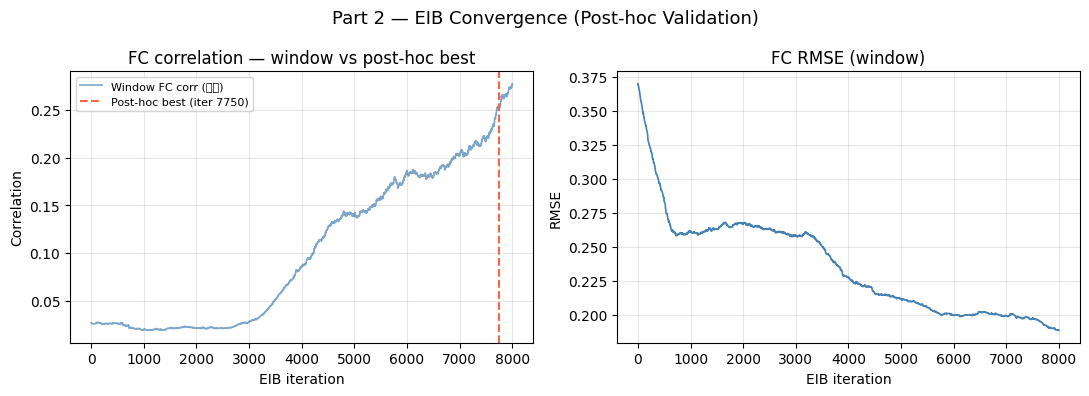

[EIB] FC comparison  pre corr=0.0189, pre rmse=0.4846  post corr=0.0862, post rmse=0.2180


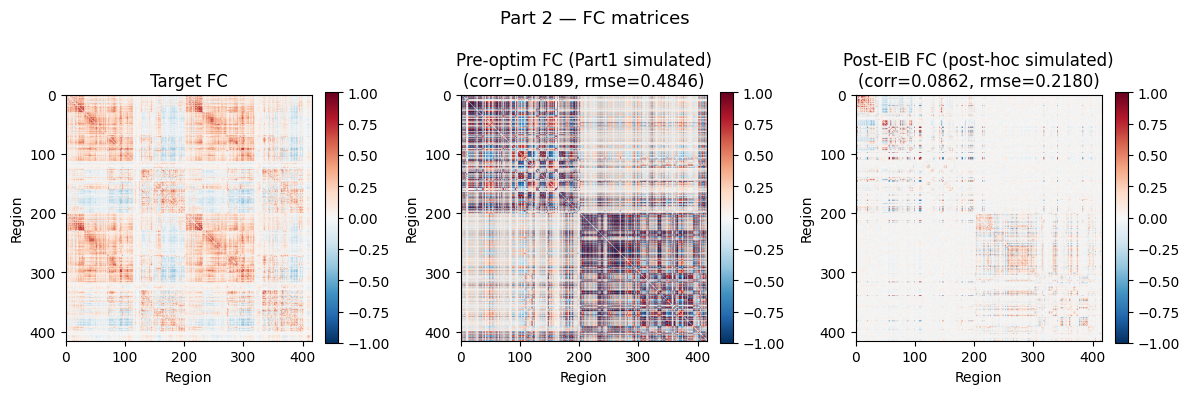

[EIB] stage=eib  c_ei_frozen=False
StateBundle(stage='eib', c_ei_frozen=False, init_dyn_shape=(2, 416))


In [8]:
# Part 2: EIB — 구버전 notebook 로직 (c_ei + wLRE/wFFI 동시 튜닝)
bundle_eib = run_eib(
    network   = network,
    bundle_in = bundle_fic,
    cfg       = cfg,
    data      = data,
)
assert not bundle_eib.params.c_ei_frozen, "Old-logic EIB should keep c_ei unfrozen"
print(f"[EIB] stage={bundle_eib.stage}  c_ei_frozen={bundle_eib.params.c_ei_frozen}")
print(bundle_eib)


## Cell 7 — Part 3: Full-matrix Gradient Optimization

구버전 notebook 로직: **96 TR / skip 8 / c_ei·wLRE·wFFI 모두 dense 최적화**.

In [9]:
# Part 3: Full-matrix Gradient Optimization
bundle_grad = run_gradient_optimization(
    network   = network,
    bundle_in = bundle_eib,
    warmup_bundle = bundle_init,
    cfg       = cfg,
    data      = data,
)
print(f"[Part3] stage={bundle_grad.stage}  c_ei_frozen={bundle_grad.params.c_ei_frozen}")
print(bundle_grad)


Running computations for grad_v_eituning_oldlogic_match_p3_p7_p8_p9_pm_p12_p13_p14_ce10_p15_p19_p21_p22_human_N416_scedc854a694_fcbcddcdeb6e_TR720_SKIP60_STEPS1000_LR0p0005_frozen0_fp2144f75e6327


W0601 16:41:50.806242 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:42:05.186211 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:42:18.370945 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:42:18.453315 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:42:18.520796 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:42:18.629421 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:42:18.714957 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:42:18.845584 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

[Part3] Initial loss: 0.893363  |  Full Corr: 0.0711
  t1_opt=720000ms (720.0s)  max_steps=1000  chunk=10  lr=0.0005  fc_skip_tr=60
[GRAD] Starting full-matrix optimization  (total 1000 steps, chunk=10)
      Step         Loss   FullCorr     BestLoss   Step/s    Elapsed        ETA
----------------------------------------------------------------------------------


W0601 16:42:23.064794 2428392 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:42:24.146720 2428571 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:42:24.146746 2428572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:42:24.146926 2428580 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:42:24.146968 2428578 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:42:24.146975 2428579 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:42:24.147049 2428577 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0601 16:42:24.147142 2428570 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

XlaRuntimeError: RESOURCE_EXHAUSTED: Failed to allocate request for 464.17GiB (498401280000B) on device ordinal 0

## Part 3B: Low-rank Gradient Optimization

사용자 지정 로직: **Low-rank는 Part 3 Full Gradient 결과를 시작점으로 사용**.

In [ ]:
# Part 3B: Low-rank Gradient Optimization (Full Gradient 결과 기반)
bundle_lowrank = run_lowrank_optimization(
    network   = network,
    bundle_in = bundle_grad,
    warmup_bundle = bundle_init,
    cfg       = cfg,
    data      = data,
)
print(f"[Part3B] stage={bundle_lowrank.stage}  c_ei_frozen={bundle_lowrank.params.c_ei_frozen}")
print(bundle_lowrank)


## Cell 8 — Part 4: DBS Stimulation

Biphasic pulse train 자극 + pre vs during PSD 비교

In [ ]:
# grad vs lowrank 중 corr이 더 높은 bundle을 DBS input으로 선택
from part3_gradient import compute_simulated_fc
from tvboptim.observations.observation import fc_corr
import jax.numpy as _jnp, numpy as _np

_fc_target = _jnp.asarray(data['fc_target'])
_sim_ms  = 180_000
_skip_tr = 30

print('\n' + '='*52)
print('  DBS input bundle 선택 (grad vs lowrank)')
print('='*52)

_fc_grad = compute_simulated_fc(network, bundle_grad, cfg, _sim_ms, _skip_tr)
_corr_grad = float(fc_corr(_jnp.asarray(_fc_grad), _fc_target))
print(f'  grad    corr={_corr_grad:.4f}')

_fc_lr = compute_simulated_fc(network, bundle_lowrank, cfg, _sim_ms, _skip_tr)
_corr_lr = float(fc_corr(_jnp.asarray(_fc_lr), _fc_target))
print(f'  lowrank corr={_corr_lr:.4f}')

print('-'*52)
if _corr_lr >= _corr_grad:
    bundle_for_dbs = bundle_lowrank
    print(f'  → DBS input: lowrank  (corr={_corr_lr:.4f})')
else:
    bundle_for_dbs = bundle_grad
    print(f'  → DBS input: grad  (corr={_corr_grad:.4f})')
print('='*52 + '\n')

run_dbs_stimulation(
    network   = network,
    bundle_in = bundle_for_dbs,
    cfg       = cfg,
    data      = data,
)

In [ ]:
from pathlib import Path
from datetime import datetime
from IPython.display import display, FileLink
import matplotlib.pyplot as plt
import zipfile
import shutil
import re

STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
SAVE_ROOT = Path(f"all_figures_export_{STAMP}")
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

# ---------------------------
# figure 저장용 helper
# ---------------------------
def _slugify(text: str) -> str:
    # 파일명으로 사용할 수 있게 텍스트 정제
    text = re.sub(r"\s+", "_", text.strip())
    text = re.sub(r"[^0-9A-Za-z가-힣_\-]+", "", text)
    return text[:120] if text else "figure"

def _infer_part_from_figure(fig) -> str:
    # Figure의 제목 정보를 바탕으로 적절한 파트 폴더 판별
    titles = []

    try:
        if getattr(fig, "_suptitle", None) is not None:
            supt = fig._suptitle.get_text()
            if supt:
                titles.append(supt)
    except Exception:
        pass

    for ax in fig.axes[:10]:
        try:
            t = ax.get_title()
            if t:
                titles.append(t)
        except Exception:
            pass

    joined = " | ".join(titles).lower()

    if "part 1" in joined or "fic" in joined:
        return "part1_fic"
    if "part 2" in joined or "eib" in joined:
        return "part2_eib"
    if "part 3b" in joined or "low-rank" in joined or "lowrank" in joined:
        return "part3b_lowrank"
    if "part 3" in joined or "gradient" in joined or "optim" in joined:
        return "part3_gradient"
    if "dbs" in joined or "lfp" in joined or "stimulus" in joined or "psd" in joined:
        return "part4_dbs"
    return "misc"

def _get_figure_title(fig, idx: int) -> str:
    # Figure의 제목을 추출하여 파일명으로 활용
    try:
        if getattr(fig, "_suptitle", None) is not None:
            supt = fig._suptitle.get_text()
            if supt:
                return supt
    except Exception:
        pass

    for ax in fig.axes:
        try:
            t = ax.get_title()
            if t:
                return t
        except Exception:
            pass

    return f"figure_{idx:03d}"

# ---------------------------
# plt.show() patch
# ---------------------------
# 기존 show 함수를 보존하고, 실행 시 저장을 먼저 하도록 패치함
if not hasattr(plt, "_oai_original_show"):
    plt._oai_original_show = plt.show

_plot_counter = {"n": 0}

def _save_all_open_figures():
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        _plot_counter["n"] += 1

        part_dir = SAVE_ROOT / _infer_part_from_figure(fig)
        part_dir.mkdir(parents=True, exist_ok=True)

        stem = _slugify(_get_figure_title(fig, _plot_counter["n"]))
        save_path_png = part_dir / f"{_plot_counter['n']:03d}_{stem}.png"
        save_path_pdf = part_dir / f"{_plot_counter['n']:03d}_{stem}.pdf"

        fig.savefig(save_path_png, dpi=300, bbox_inches="tight")
        fig.savefig(save_path_pdf, bbox_inches="tight")

def _patched_show(*args, **kwargs):
    _save_all_open_figures()
    return plt._oai_original_show(*args, **kwargs)

plt.show = _patched_show

print(f"[INFO] Auto-save patch installed -> {SAVE_ROOT.resolve()}")

# ---------------------------
# 기존 DBS 결과 폴더 정리
# ---------------------------
try:
    dbs_dir = Path(cfg.dbs_output_base_dir)
    if dbs_dir.exists():
        shutil.rmtree(dbs_dir)
except Exception:
    pass

# ---------------------------
# Part 1 ~ Part 4 재실행
# ---------------------------
print("[INFO] Re-running Part 1~4...")

bundle_fic = run_fic(
    network=network,
    bundle_in=bundle_init,
    cfg=cfg,
    data=data,
)

bundle_eib = run_eib(
    network=network,
    bundle_in=bundle_fic,
    cfg=cfg,
    data=data,
)

bundle_grad = run_gradient_optimization(
    network=network,
    bundle_in=bundle_eib,
    warmup_bundle=bundle_init,
    cfg=cfg,
    data=data,
)

bundle_final = bundle_grad
if "run_lowrank_optimization" in globals():
    try:
        bundle_lowrank = run_lowrank_optimization(
            network=network,
            bundle_in=bundle_grad,
            warmup_bundle=bundle_init,
            cfg=cfg,
            data=data,
        )
        bundle_final = bundle_lowrank
    except Exception as e:
        print(f"[WARN] Low-rank skipped: {e}")

# DBS 재실행 (DBS는 시뮬레이션 결과가 매번 생성됨)
try:
    run_dbs_stimulation(
        network=network,
        optimized_state=bundle_final,
        cfg=cfg,
        data=data,
    )
except TypeError:
    run_dbs_stimulation(
        network,
        bundle_final,
        cfg,
        data,
    )

# ---------------------------
# DBS 결과 파일(CSV 등)도 함께 복사
# ---------------------------
try:
    dbs_dir = Path(cfg.dbs_output_base_dir)
except Exception:
    dbs_dir = Path("dbs_analysis")

if dbs_dir.exists():
    copied = SAVE_ROOT / "part4_dbs" / "dbs_analysis_files"
    copied.parent.mkdir(parents=True, exist_ok=True)
    if copied.exists():
        shutil.rmtree(copied)
    shutil.copytree(dbs_dir, copied)

# ---------------------------
# zip 생성 및 다운로드 링크 제공
# ---------------------------
zip_path = Path(f"all_figures_export_{STAMP}.zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in SAVE_ROOT.rglob("*"):
        if p.is_file():
            zf.write(p, p.relative_to(SAVE_ROOT.parent))

print(f"[INFO] Saved ZIP -> {zip_path.resolve()}")
display(FileLink(str(zip_path)))

In [ ]:
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = Path(f"paper_figures_{STAMP}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def find_first_file(root: Path, filename: str):
    matches = list(root.rglob(filename))
    if not matches:
        return None
    matches.sort(key=lambda p: len(p.parts))
    return matches[0]

# 4개 region 이름
target_labels = list(cfg.dbs_target_regions.keys())[:4]

fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)

for ax, target_label in zip(axes, target_labels):
    target_dir = Path(cfg.dbs_output_base_dir) / target_label
    psd_csv = find_first_file(target_dir, "psd_pre_vs_during.csv")

    if psd_csv is None:
        ax.set_title(f"{target_label} (PSD file not found)")
        ax.axis("off")
        continue

    df = pd.read_csv(psd_csv)

    freq_col = None
    pre_col = None
    during_col = None

    for c in df.columns:
        cl = c.lower()
        if "freq" in cl:
            freq_col = c
        elif "pre" in cl and "psd" in cl:
            pre_col = c
        elif "during" in cl and "psd" in cl:
            during_col = c

    if freq_col is None or pre_col is None or during_col is None:
        ax.set_title(f"{target_label} (Unexpected PSD CSV format)")
        ax.axis("off")
        continue

    freq = np.asarray(df[freq_col], dtype=np.float32)
    psd_pre = np.asarray(df[pre_col], dtype=np.float32)
    psd_during = np.asarray(df[during_col], dtype=np.float32)

    mask = freq <= 100.0
    freq = freq[mask]
    psd_pre = psd_pre[mask]
    psd_during = psd_during[mask]

    ax.plot(freq, psd_pre, linewidth=1.8, label="Pre")
    ax.plot(freq, psd_during, linewidth=1.8, label="During")
    
    # Y축 로그 스케일 적용
    ax.set_yscale('log')
    
    ax.set_xlim(0, 100)
    ax.set_title(target_label, fontsize=12)
    ax.set_ylabel("PSD (Log Scale)")
    
    # 그리드 설정 (로그 스케일 시 major/minor 그리드 모두 표시하면 가독성이 좋아짐)
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
    ax.legend(fontsize=9, loc="upper right")

axes[-1].set_xlabel("Frequency (Hz)")

fig.tight_layout()

save_png = OUT_DIR / "DBS_PSD_4regions_stacked_log.png"
save_pdf = OUT_DIR / "DBS_PSD_4regions_stacked_log.pdf"

fig.savefig(save_png, dpi=300, bbox_inches="tight")
fig.savefig(save_pdf, bbox_inches="tight")
plt.show()

print(f"Saved: {save_png.resolve()}")
print(f"Saved: {save_pdf.resolve()}")